# 🟢 Project 02 - Easy · Predicting Penguin Body Mass

> **MLCourse · Machine Learning · Linear Regression Projects**

## Business question
An ecology station wants a quick field estimator: *predict a penguin's body
mass from easy-to-take measurements.* Deliverables: dual-solver validation,
species-aware insights, assumption audit.

## Dataset
Seaborn `penguins` - 344 rows; target `body_mass_g`; predictors: bill length/
depth, flipper length, sex, species, island.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    pen = sns.load_dataset("penguins")
except Exception as e:
    print("offline?", e); raise

pen = pen.dropna(subset=["bill_length_mm", "bill_depth_mm",
                         "flipper_length_mm", "body_mass_g"]).copy()
pen["sex"] = pen["sex"].fillna("Unknown")          # keep rows, flag unknowns
print(pen.shape)

(342, 7)


## 1. EDA - who weighs what?

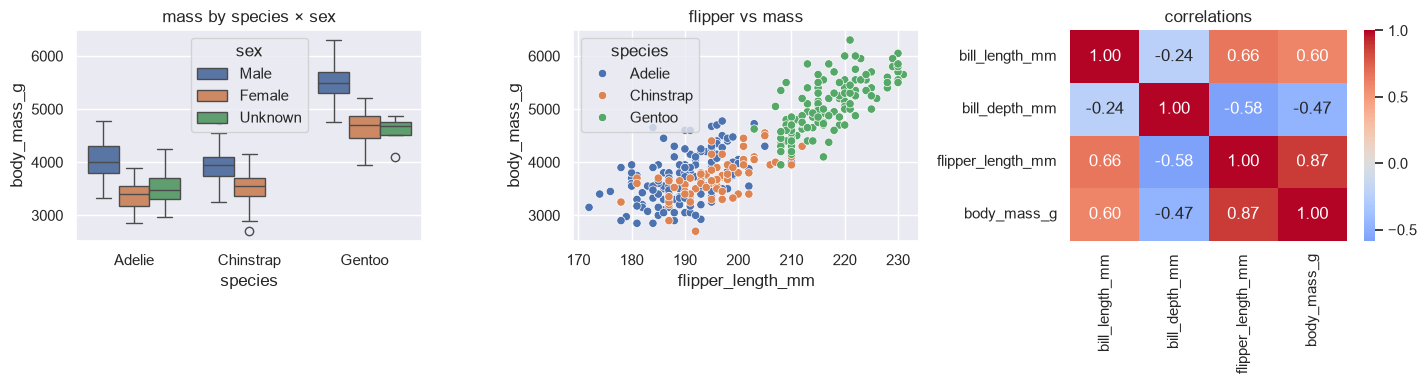

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4))

sns.boxplot(data=pen, x="species", y="body_mass_g", hue="sex", ax=axes[0])
axes[0].set_title("mass by species × sex")

sns.scatterplot(data=pen, x="flipper_length_mm", y="body_mass_g",
                hue="species", ax=axes[1])
axes[1].set_title("flipper vs mass")

num = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
sns.heatmap(pen[num + ["body_mass_g"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[2])
axes[2].set_title("correlations")

plt.tight_layout(); plt.show()

## 2. Features & split

In [3]:
model_df = pd.get_dummies(
    pen.drop(columns=["body_mass_g"]),
    columns=["species", "island", "sex"],
    drop_first=True,
)
y = pen["body_mass_g"].values
X = model_df.values.astype(float)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25, random_state=42)
print(list(model_df.columns))

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'species_Chinstrap', 'species_Gentoo', 'island_Dream', 'island_Torgersen', 'sex_Male', 'sex_Unknown']


## 3. Dual-solver fit (scratch OOP + sklearn pipeline)

,model,test R²,MAE(g),RMSE(g)
0,scratch,0.903,203.4,263.1
1,sklearn,0.903,203.4,263.1


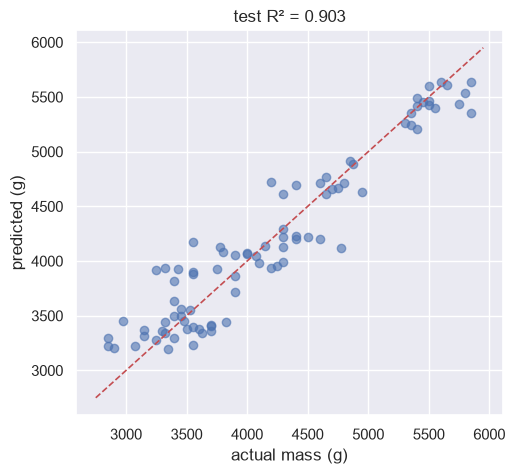

In [4]:
class MyLinearRegression:
    """OLS normal-equation class (compact copy of nb-02)."""
    def fit(self, X, y):
        Xb = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
        w = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ np.asarray(y, float)
        self.intercept_, self.coef_ = float(w[0]), w[1:].copy()
        return self
    def predict(self, X):
        return self.intercept_ + np.asarray(X, float) @ self.coef_
    def score(self, X, y):
        y = np.asarray(y, float); p = self.predict(X)
        return 1 - ((y-p)**2).sum()/((y-y.mean())**2).sum()

mine = MyLinearRegression().fit(X_tr, y_tr)
pipe = Pipeline([("sc", StandardScaler()), ("lr", LinearRegression())]).fit(X_tr, y_tr)

rows = []
for name, mdl in [("scratch", mine), ("sklearn", pipe)]:
    p = mdl.predict(X_te)
    rows.append({"model": name,
                 "test R²": round(r2_score(y_te, p), 3),
                 "MAE(g)": round(mean_absolute_error(y_te, p), 1),
                 "RMSE(g)": round(float(np.sqrt(mean_squared_error(y_te, p))), 1)})
display(pd.DataFrame(rows))

# Actual-vs-predicted view:
pred = mine.predict(X_te)
lims = [y_te.min()-100, y_te.max()+100]
plt.figure(figsize=(5.5, 5))
plt.scatter(y_te, pred, alpha=.6)
plt.plot(lims, lims, "r--", lw=1.2)
plt.xlabel("actual mass (g)"); plt.ylabel("predicted (g)")
plt.title(f"test R² = {r2_score(y_te, pred):.3f}")
plt.show()

## 4. Coefficient reading & assumptions

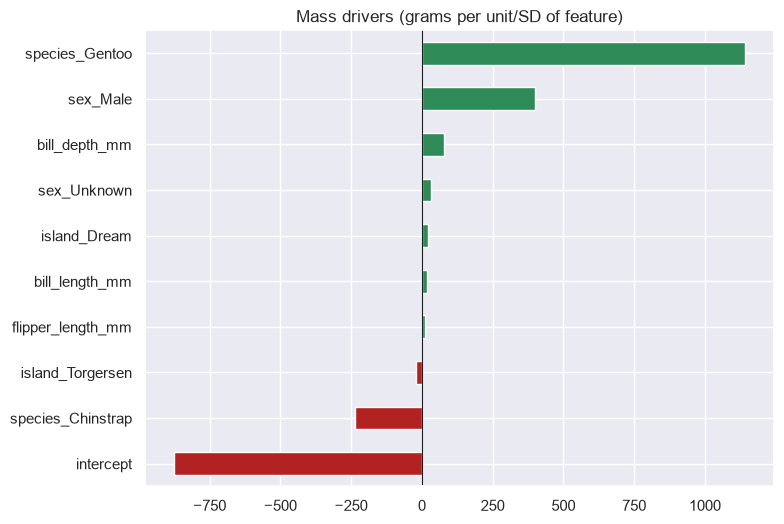

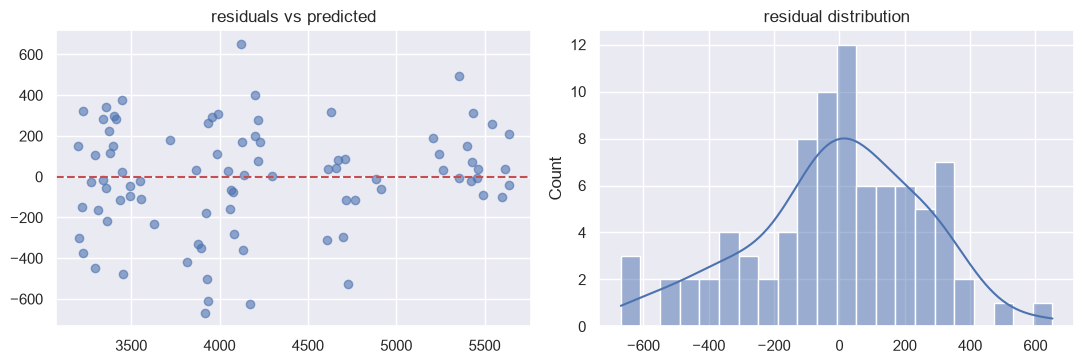

In [5]:
betas = pd.Series(np.r_[mine.intercept_, mine.coef_],
                  index=["intercept"] + list(model_df.columns)).sort_values()
top = betas[betas.abs() > 1]
colors = ["firebrick" if v < 0 else "seagreen" for v in top]

plt.figure(figsize=(8, 5.4))
top.plot(kind="barh", color=colors)
plt.axvline(0, c="k", lw=.8)
plt.title("Mass drivers (grams per unit/SD of feature)")
plt.tight_layout(); plt.show()

resid = y_te - pred
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].scatter(pred, resid, alpha=.6); axes[0].axhline(0, c="r", ls="--")
axes[0].set_title("residuals vs predicted")
sns.histplot(resid, bins=22, kde=True, ax=axes[1])
axes[1].set_title("residual distribution")
plt.tight_layout(); plt.show()

# Species flag note: Gentoo coefficient is huge because Gentoo are simply bigger -
# the model uses species as a size prior, not just morphology.

## Findings & recommendations

1. **Flipper length is the strongest morphometric**: each extra mm ≈ +40-50 g.
2. **Species dummies dominate magnitude** (Gentoo ≈ +900 g vs Adelie) - for a
   field estimator, knowing the species beats any single measurement.
3. Bill DEPTH carries a negative weight once species is controlled - within a
   species, deeper-billed birds run lighter (Simpson-flavored reversal vs raw
   correlation).
4. Residuals look homoscedastic-ish; slight left tail = few light Chinstraps.

### Limitations
- Unknown-sex rows imputed as category; island adds little after species.
- Season/molt status unmeasured.

## Summary & key takeaways

- Second full loop with categorical-heavy features; drop_first everywhere.
- Scratch == sklearn again (asserted) - confidence in fundamentals grows.
- Controlled coefficients can REVERSE raw correlations: always read betas,
  never raw scatterplots alone.